In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : Handwritten Digit Classification (Digits 8×8)
Algorithm       : Bidirectional LSTM (BiLSTM) – completely from scratch

Description     : Full manual implementation of a Bidirectional LSTM network 
                  without using any high-level recurrent layers (nn.LSTM, etc.).

                  Implemented components from scratch:
                  - Forward LSTM and Backward LSTM
                  - Forget, Input, Cell, and Output gates
                  - Xavier & Orthogonal weight initialization
                  - Forward propagation through time
                  - Backpropagation Through Time (BPTT) for both directions
                  - Softmax output for multi-class classification

                  The 8×8 digit images are treated as sequences of length 8 
                  with 8 features per time step.

                  Part of the comprehensive Deep Learning course.

Full video course (theory + equations + step-by-step implementation):
https://onlinebme.com/
https://onlinebme.com/product/implementing-neural-networks-with-pytorch/
============================================================================
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#%% load dataset 
ds= load_digits()
data= ds['data']
target= ds['target']
print(data.shape,target.shape)

(1797, 64) (1797,)


In [3]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                                 train_size=0.7,
                                                 shuffle=True)

In [4]:
# standardize
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xtest= scaler.transform(Xtest)

In [5]:
#%% convert to tensor
Xtrain= torch.from_numpy(Xtrain).type(torch.float32).unsqueeze(2)
y_train= torch.from_numpy(y_train).type(torch.float32)
y_train_onhot=(y_train.reshape(-1,1)==
               torch.arange(10).reshape(1,-1)).type(torch.float32)



Xtest= torch.from_numpy(Xtest).type(torch.float32).unsqueeze(2)
y_test= torch.from_numpy(y_test).type(torch.float32)
y_test_onhot=(y_test.reshape(-1,1)==torch.arange(10).reshape(1,-1)).type(torch.float32)

In [6]:
class Customdataset(Dataset):
    def __init__(self,data,label):
        super().__init__()
        self.data= data
        self.label= label
    def __len__(self):
        return self.label.shape[0]
    def __getitem__(self, index):
        x= self.data[index]
        y= self.label[index]
        
        x= x.reshape(8,8)
        # x= x.permute(1,0)
        # x= x.reshape(64,1)
        return x,y
        

In [7]:
#% build data loader 
# ds= TensorDataset(Xtrain,y_train_onhot)
ds= Customdataset(Xtrain,y_train_onhot)
train_loader= DataLoader(ds,batch_size=32,
                         shuffle=False,
                         drop_last=True)

In [8]:
def xavier_init(shape):
    fan_in, fan_out = shape[1], shape[0]
    # limit = torch.sqrt(torch.tensor(6.0 / (fan_in + fan_out)))
    # w= torch.empty(shape).uniform_(-limit, limit)
    sigma= torch.sqrt(torch.tensor(2 / (fan_in + fan_out)))
    w= torch.randn(shape)*sigma
    return w
def orthogonal_init(shape):
    # shape = (n_hidden, n_hidden)
    W = torch.randn(shape)
    q, r = torch.linalg.qr(W)
    # Ensure determinant is positive (for orthogonal)
    if torch.det(q) < 0:
        q[:, 0] = -q[:, 0]
    return q

class BiLSTMManual():
    def __init__(self, n_features, n_hidden, n_out, 
                 lr=0.001):
        # dims
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_out = n_out
        self.lr = lr
        self.lstm1= self.lstm_params_init(n_features,n_hidden)
        self.lstm2= self.lstm_params_init(n_features,n_hidden)
        
                # Output layer parameters (n_out, n_hidden)
        self.wy = xavier_init((n_out, n_hidden*2) )
        self.by = xavier_init((n_out, 1))
        self.dwy = torch.zeros_like(self.wy)
        self.dby = torch.zeros_like(self.by)
        
    class lstm_params_init():
        def __init__(self,n_features,n_hidden):  
            # Input-to-gate weights (W), shape (n_hidden, n_features)
            self.Wf = xavier_init((n_hidden, n_features) )
            self.Wi = xavier_init((n_hidden, n_features) )
            self.Wg = xavier_init((n_hidden, n_features) )
            self.Wo = xavier_init((n_hidden, n_features)) 
            # Hidden-to-gate weights (U), shape (n_hidden, n_hidden)
            self.Uf = orthogonal_init((n_hidden, n_hidden))# + torch.eye(n_hidden, n_hidden) * wrate#
            self.Ui = orthogonal_init((n_hidden, n_hidden))#+ torch.eye(n_hidden, n_hidden) * wrate
            self.Ug = orthogonal_init((n_hidden, n_hidden)) #+ torch.eye(n_hidden, n_hidden) * wrate
            self.Uo = orthogonal_init((n_hidden, n_hidden)) #+ torch.eye(n_hidden, n_hidden) * wrate

            # biases (n_hidden, 1)
            self.bf = torch.zeros(n_hidden, 1) 
            self.bi = torch.zeros(n_hidden, 1)
            self.bg = torch.zeros(n_hidden, 1)  
            self.bo = torch.zeros(n_hidden, 1) 

            # Grad accumulators (same shapes)
            self.dWf = torch.zeros_like(self.Wf)
            self.dWi = torch.zeros_like(self.Wi)
            self.dWg = torch.zeros_like(self.Wg)
            self.dWo = torch.zeros_like(self.Wo)

            self.dUf = torch.zeros_like(self.Uf)
            self.dUi = torch.zeros_like(self.Ui)
            self.dUg = torch.zeros_like(self.Ug)
            self.dUo = torch.zeros_like(self.Uo)

            self.dbf = torch.zeros_like(self.bf)
            self.dbi = torch.zeros_like(self.bi)
            self.dbg = torch.zeros_like(self.bg)
            self.dbo = torch.zeros_like(self.bo)

    # --- call/forward API similar to your RNN ---
    def __call__(self, x, h0=None, c0=None,h0_2=None, c0_2=None):
        return self.forward(x, h0, c0,h0_2,c0_2)

    def forward(self, x, h0=None, c0=None,h0_2= None,c0_2= None):
        batch_size, T, _ = x.size()
        n_h = self.n_hidden

        # initialize
        if h0 is None:
            h_prev1 = torch.zeros(n_h, batch_size)
            c_prev1 = torch.zeros(n_h, batch_size)
            
            h_prev2 = torch.zeros(n_h, batch_size)
            c_prev2 = torch.zeros(n_h, batch_size)
        else:
            h_prev1 = h0  # assumed shape (n_hidden, batch_size)
            c_prev1 = c0
            h_prev2 = h0_2  # assumed shape (n_hidden, batch_size)
            c_prev2 = c0_2
            

        yos = []
        # hts = []
        # We'll save per-timestep values needed for backprop
        saved1 = {
            "x": [],       # xt (n_features, batch)
            "h_prev": [],  # h_{t-1}
            "c_prev": [],  # c_{t-1}
            "f": [], "i": [], "g": [], "o": [], "c": [], "h": []
        }
        
        saved2 = {
            "x": [],       # xt (n_features, batch)
            "h_prev": [],  # h_{t-1}
            "c_prev": [],  # c_{t-1}
            "f": [], "i": [], "g": [], "o": [], "c": [], "h": []
        }

        for t in range(T):
            xt_first = x[:, t, :].T   # (n_f, b_s)
            xt_last= x[:, T-t-1, :].T   # (n_f, b_s)
            # gate pre-activations and activations
            zf1 = self.lstm1.Wf @ xt_first + self.lstm1.Uf @ h_prev1 + self.lstm1.bf   # (n_h, b_s)
            zi1 = self.lstm1.Wi @ xt_first + self.lstm1.Ui @ h_prev1 + self.lstm1.bi
            zg1 = self.lstm1.Wg @ xt_first + self.lstm1.Ug @ h_prev1 + self.lstm1.bg
            zo1 = self.lstm1.Wo @ xt_first + self.lstm1.Uo @ h_prev1 + self.lstm1.bo

            f_t1 = torch.sigmoid(zf1)# (n_h, b_s)
            i_t1 = torch.sigmoid(zi1)
            g_t1 = torch.tanh(zg1)
            o_t1 = torch.sigmoid(zo1)

            c_t1 = f_t1 * c_prev1 + i_t1 * g_t1 # (n_h, b_s)
            tanh_c_t1 = torch.tanh(c_t1) # (n_h, b_s)
            h_t1 = o_t1 * tanh_c_t1 # (n_h, b_s)
            
            
            zf = self.lstm2.Wf @ xt_last + self.lstm2.Uf @ h_prev2 + self.lstm2.bf   # (n_h, b_s)
            zi = self.lstm2.Wi @ xt_last + self.lstm2.Ui @ h_prev2 + self.lstm2.bi
            zg = self.lstm2.Wg @ xt_last + self.lstm2.Ug @ h_prev2 + self.lstm2.bg
            zo = self.lstm2.Wo @ xt_last + self.lstm2.Uo @ h_prev2 + self.lstm2.bo

            f_t = torch.sigmoid(zf)# (n_h, b_s)
            i_t = torch.sigmoid(zi)
            g_t = torch.tanh(zg)
            o_t = torch.sigmoid(zo)

            c_t = f_t * c_prev2 + i_t * g_t # (n_h, b_s)
            tanh_c_t = torch.tanh(c_t) # (n_h, b_s)
            h_t = o_t * tanh_c_t # (n_h, b_s)
            
            hh_concat= torch.concat((h_t1,h_t),dim=0)

            # output (softmax over dim=0 to match your RNN behavior)
            vout = self.wy @ hh_concat + self.by           # (n_out, b_size)
            y_t = torch.softmax(vout, dim=0)

            # save
            yos.append(y_t)
            # hts.append(h_t)
            # saved["x"].append(xt)
            saved1["h_prev"].append(h_prev1)
            saved1["c_prev"].append(c_prev1)
            saved1["f"].append(f_t1)
            saved1["i"].append(i_t1)
            saved1["g"].append(g_t1)
            saved1["o"].append(o_t1)
            saved1["c"].append(c_t1)
            saved1["h"].append(h_t1)
            
            saved2["h_prev"].append(h_prev2)
            saved2["c_prev"].append(c_prev2)
            saved2["f"].append(f_t)
            saved2["i"].append(i_t)
            saved2["g"].append(g_t)
            saved2["o"].append(o_t)
            saved2["c"].append(c_t)
            saved2["h"].append(h_t)

            # step
            h_prev1 = h_t1
            c_prev1 = c_t1
            h_prev2 = h_t
            c_prev2 = c_t

        return yos,saved1,saved2

    # --- Backprop through time (manual) ---
    def backward(self, x, y_true, y_pred_list, saved1,saved2):
        # x= saved['x'] 
        h_prev_list1= saved1["h_prev"] 
        c_prev_list1= saved1["c_prev"]
        f1= saved1["f"]
        i1= saved1["i"]
        g1= saved1["g"]
        o1= saved1["o"]
        c1= saved1["c"]
        h1= saved1["h"]
        
        h_prev_list2= saved2["h_prev"] 
        c_prev_list2= saved2["c_prev"]
        f2= saved2["f"]
        i2= saved2["i"]
        g2= saved2["g"]
        o2= saved2["o"]
        c2= saved2["c"]
        h2= saved2["h"]
        
        n_hidden= self.n_hidden
        b_size,T,_= x.size()
        
        y_T= y_pred_list[-1] # n_out x b_s 
        d_T=  y_true.T# n_out x b_s 
        
        hh_concat= torch.concat((h1[-1],h2[-1]),dim=0).T
        
        delta_o= d_T-y_T # n_out x b_s 
        self.dwy= delta_o@ hh_concat # n_out x b_s 
        self.dby= torch.sum(delta_o,dim=1,keepdim=True)# n_out x 1
        
        dh_next1= torch.zeros(b_size,n_hidden)
        dc_next1= torch.zeros(b_size,n_hidden)
        
        dh_next2= torch.zeros(b_size,n_hidden)
        dc_next2= torch.zeros(b_size,n_hidden)
        
        for t in reversed(range(T)):
            xt_first= x[:,t,:]#  b_s * n_f
            xt_last= x[:,T-t-1,:]#  b_s * n_f
            ft1= f1[t].T # (n_h, b_s)
            it1= i1[t].T
            ot1= o1[t].T
            gt1= g1[t].T
            ct1= c1[t].T
            c_prev1=c_prev_list1[t].T
            h_prev1=h_prev_list1[t].T
            
            ft2= f2[t].T # (n_h, b_s)
            it2= i2[t].T
            ot2= o2[t].T
            gt2= g2[t].T
            ct2= c2[t].T
            c_prev2=c_prev_list2[t].T
            h_prev2=h_prev_list2[t].T
            
            # dh from output and next step
            if t==T-1:
                dh = delta_o.T @ self.wy
                dht1= dh[:,:n_hidden]
                dht2= dh[:,n_hidden:]
                dct1 = dht1 * ot1 * (1 - torch.tanh(ct1)**2)
                dct2 = dht2 * ot2 * (1 - torch.tanh(ct2)**2)
            else:
                dht1 =  dh_next1  
                dct1 = dc_next1  
                dht2 =  dh_next2  
                dct2 = dc_next2  
            
            # b_s x n_h
            dgt1= dct1 * (it1)
            dft1= dct1 * (c_prev1)
            dot1= dht1* (torch.tanh(ct1))
            dit1= dct1* (gt1)

            
            dzf1= (dft1 * (ft1*(1-ft1))).T
            dzi1= (dit1 * (it1*(1-it1))).T
            dzo1= (dot1 * (ot1*(1-ot1))).T
            dzg1= (dgt1 * ((1-gt1.pow(2)))).T
            
            
            self.lstm1.dWf+= dzf1 @ xt_first
            self.lstm1.dWi+= dzi1 @ xt_first
            self.lstm1.dWo+= dzo1 @ xt_first
            self.lstm1.dWg+= dzg1 @ xt_first
            
            self.lstm1.dUf+= dzf1 @ h_prev1
            self.lstm1.dUi+= dzi1 @ h_prev1
            self.lstm1.dUo+= dzo1 @ h_prev1
            self.lstm1.dUg+= dzg1 @ h_prev1
            
            
            self.lstm1.dbf += torch.sum(dzf1, dim=1, keepdims=True)
            self.lstm1.dbi += torch.sum(dzi1, dim=1, keepdims=True)
            self.lstm1.dbo += torch.sum(dzo1, dim=1, keepdims=True)
            self.lstm1.dbg += torch.sum(dzg1, dim=1, keepdims=True)
            
            dh_next1 =( dzf1.T @ self.lstm1.Uf) + (dzi1.T @ self.lstm1.Ui) +\
                     (dzo1.T @ self.lstm1.Uo) + (dzg1.T @ self.lstm1.Ug)

            dc_next1 = dct1 * ft1
            
            
             # b_s x n_h
            dgt2= dct2 * (it2)
            dft2= dct2 * (c_prev2)
            dot2= dht2* (torch.tanh(ct2))
            dit2= dct2* (gt2)

            
            dzf2= (dft2 * (ft2*(1-ft2))).T
            dzi2= (dit2 * (it2*(1-it2))).T
            dzo2= (dot2 * (ot2*(1-ot2))).T
            dzg2= (dgt2 * ((1-gt2.pow(2)))).T
            
            
            self.lstm2.dWf+= dzf2 @ xt_last
            self.lstm2.dWi+= dzi2 @ xt_last
            self.lstm2.dWo+= dzo2 @ xt_last
            self.lstm2.dWg+= dzg2 @ xt_last
            
            self.lstm2.dUf+= dzf2 @ h_prev2
            self.lstm2.dUi+= dzi2 @ h_prev2
            self.lstm2.dUo+= dzo2 @ h_prev2
            self.lstm2.dUg+= dzg2 @ h_prev2
            
            
            self.lstm2.dbf += torch.sum(dzf2, dim=1, keepdims=True)
            self.lstm2.dbi += torch.sum(dzi2, dim=1, keepdims=True)
            self.lstm2.dbo += torch.sum(dzo2, dim=1, keepdims=True)
            self.lstm2.dbg += torch.sum(dzg2, dim=1, keepdims=True)
            
            dh_next2 =( dzf2.T @ self.lstm2.Uf) + (dzi2.T @ self.lstm2.Ui) +\
                     (dzo2.T @ self.lstm2.Uo) + (dzg2.T @ self.lstm2.Ug)

            dc_next2 = dct2 * ft2
        
        # self.dWf/=b_size
        # self.dWi/=b_size
        # self.dWg/=b_size
        # self.dWo/=b_size

        # self.dUf/=b_size
        # self.dUi/=b_size
        # self.dUg/=b_size
        # self.dUo/=b_size

        # self.dbf/=b_size
        # self.dbi/=b_size
        # self.dbg/=b_size
        # self.dbo/=b_size

        # self.dwy/=b_size
        # self.dby/=b_size
              
    # reset grads
    def zero_grad(self):
        self.lstm1.dWf.zero_()
        self.lstm1.dWi.zero_()
        self.lstm1.dWg.zero_()
        self.lstm1.dWo.zero_()

        self.lstm1.dUf.zero_()
        self.lstm1.dUi.zero_()
        self.lstm1.dUg.zero_()
        self.lstm1.dUo.zero_()

        self.lstm1.dbf.zero_()
        self.lstm1.dbi.zero_()
        self.lstm1.dbg.zero_()
        self.lstm1.dbo.zero_()
        
        self.lstm2.dWf.zero_()
        self.lstm2.dWi.zero_()
        self.lstm2.dWg.zero_()
        self.lstm2.dWo.zero_()

        self.lstm2.dUf.zero_()
        self.lstm2.dUi.zero_()
        self.lstm2.dUg.zero_()
        self.lstm2.dUo.zero_()

        self.lstm2.dbf.zero_()
        self.lstm2.dbi.zero_()
        self.lstm2.dbg.zero_()
        self.lstm2.dbo.zero_()

        self.dwy.zero_()
        self.dby.zero_()
        
    def clipping(self,grad_clip_val):
          params= [self.dWf,self.dWi,self.dWg,self.dWo,
            self.dUf,self.dUi,self.dUg,self.dUo,
            self.dbf,self.dbi,self.dbg,self.dbo,
            self.dwy,self.dby]
          norm = torch.sqrt(sum(torch.sum((p ** 2)) for p in params))
          if norm > grad_clip_val:
               for param in params:
                    param.mul_(grad_clip_val / norm) 
        
            # for attr in ['dWf','dWi','dWg','dWo','dUf','dUi','dUg','dUo','dbf','dbi','dbg',
            #          'dbo','dwy','dby']:
            # getattr(self, attr).zero_()
    # SGD-like step (add gradients scaled by lr)
    def step(self):
        self.lstm1.Wf += self.lr * self.lstm1.dWf
        self.lstm1.Wi += self.lr * self.lstm1.dWi
        self.lstm1.Wg += self.lr * self.lstm1.dWg
        self.lstm1.Wo += self.lr * self.lstm1.dWo

        self.lstm1.Uf += self.lr * self.lstm1.dUf
        self.lstm1.Ui += self.lr * self.lstm1.dUi
        self.lstm1.Ug += self.lr * self.lstm1.dUg
        self.lstm1.Uo += self.lr * self.lstm1.dUo

        self.lstm1.bf += self.lr * self.lstm1.dbf
        self.lstm1.bi += self.lr * self.lstm1.dbi
        self.lstm1.bg += self.lr * self.lstm1.dbg
        self.lstm1.bo += self.lr * self.lstm1.dbo
        
        
        self.lstm2.Wf += self.lr * self.lstm2.dWf
        self.lstm2.Wi += self.lr * self.lstm2.dWi
        self.lstm2.Wg += self.lr * self.lstm2.dWg
        self.lstm2.Wo += self.lr * self.lstm2.dWo

        self.lstm2.Uf += self.lr * self.lstm2.dUf
        self.lstm2.Ui += self.lr * self.lstm2.dUi
        self.lstm2.Ug += self.lr * self.lstm2.dUg
        self.lstm2.Uo += self.lr * self.lstm2.dUo

        self.lstm2.bf += self.lr * self.lstm2.dbf
        self.lstm2.bi += self.lr * self.lstm2.dbi
        self.lstm2.bg += self.lr * self.lstm2.dbg
        self.lstm2.bo += self.lr * self.lstm2.dbo

        self.wy += self.lr * self.dwy
        self.by += self.lr * self.dby

    def mse(self, y_true, y_pred):
        # y_true: (batch, n_out), y_pred: list of outputs (n_out, batch)
        y_true_T = y_true.T
        y_pred_last = y_pred[-1]
        e = y_true_T - y_pred_last
        return torch.mean(e ** 2)
     
    def g_tanh(self,y):
        return (1-y**2)

    def g_sigmoid(self,y):
        return y*(1-y)

    def g_relu(self,y):
        yhat= (y>0).type(torch.float32)
        return yhat

    def g_linear(self,y):
        return torch.ones(y.size())


In [9]:
#%% train Neural Network
torch.manual_seed(1)
lr=0.1
n_out= 10
n_hid1= 128

n_features=8
mdl = BiLSTMManual(n_features, 
                 n_hid1, n_out, 
                 lr)

In [10]:
mse=[]
epoch=30
h0=None
c0= None
h0_2=None
c0_2= None
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          # farward pass
          # ypred,hts,hps= mdl(xbatch)
          ypred_list, saved1, saved2 = mdl.forward(xbatch,h0,c0,h0_2,c0_2)
          h0= saved1['h'][-1]
          c0= saved1['c'][-1]
          h0_2= saved2['h'][-1]
          c0_2= saved2['c'][-1]
          loss = mdl.mse(ybatch, ypred_list)
          mdl.backward(xbatch, ybatch, ypred_list, saved1,saved2)
          # mdl.clipping(1)
          mdl.step()
          mdl.zero_grad()

          # mdl.backward(xbatch,ybatch,ypred,hts,hps) 
          # mdl.step()
          er.append(loss)
          # er.append(mdl.mse(ybatch,ypred[-1])) 
          # print(er[i])

     loss= torch.mean(torch.tensor(er))
     mse.append(loss)
     print(f'MSE({iter}): {mse[iter]:.8f}')

mse=torch.tensor(mse)


MSE(0): 0.03702730
MSE(1): 0.01067593
MSE(2): 0.00581941
MSE(3): 0.00285264
MSE(4): 0.00137696
MSE(5): 0.00077863
MSE(6): 0.00036619
MSE(7): 0.00011480
MSE(8): 0.00005426
MSE(9): 0.00002753
MSE(10): 0.00001690
MSE(11): 0.00001167
MSE(12): 0.00000865
MSE(13): 0.00000669
MSE(14): 0.00000532
MSE(15): 0.00000433
MSE(16): 0.00000359
MSE(17): 0.00000301
MSE(18): 0.00000256
MSE(19): 0.00000220
MSE(20): 0.00000191
MSE(21): 0.00000167
MSE(22): 0.00000147
MSE(23): 0.00000131
MSE(24): 0.00000116
MSE(25): 0.00000104
MSE(26): 0.00000094
MSE(27): 0.00000085
MSE(28): 0.00000077
MSE(29): 0.00000071


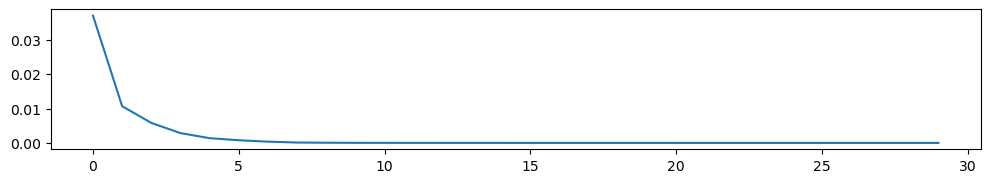

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(mse)
plt.show()

In [12]:
#%% test trained Neural Network
ds_test= Customdataset(Xtest,y_test)
ypred=[]
h0=None
c0=None
h0_2=None
c0_2=None
for i in range(Xtest.size(0)):
    xt= ds_test[i][0]
    xt= xt.unsqueeze(0)
    # yp= mdl(xt)[0]
    ypred_list, saved1,saved2 = mdl.forward(xt,h0,c0,h0_2,c0_2)
    h0= saved1['h'][-1]
    c0= saved1['c'][-1]
    h0_2= saved2['h'][-1]
    c0_2= saved2['c'][-1]
    yp=ypred_list[-1]
    yp= torch.argmax(yp.T,dim=1)
    ypred.append(yp)

ypred= np.array(ypred)

In [13]:
ypred.shape

(540, 1)

In [14]:
ypred=ypred.flatten()
d_test= y_test.flatten()

print(ypred.shape,d_test.shape,Xtest.shape,yp[-1].shape,Xtest[i].shape)

(540,) torch.Size([540]) torch.Size([540, 64, 1]) torch.Size([]) torch.Size([64, 1])


Total accuracy:97.222%
accuracy0:97.872%
accuracy1:100.000%
accuracy2:98.361%
accuracy3:94.231%
accuracy4:100.000%
accuracy5:98.077%
accuracy6:100.000%
accuracy7:100.000%
accuracy8:90.625%
accuracy9:94.444%


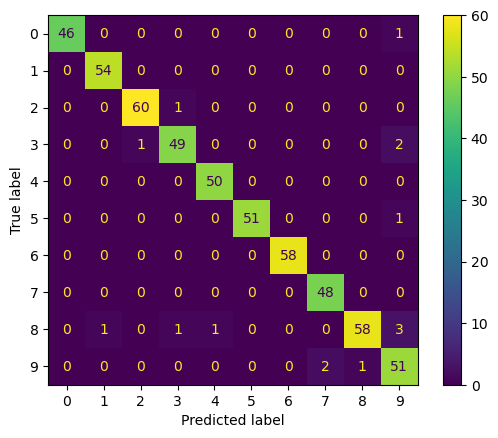

In [15]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
#%% test trained Neural Network
C= confusion_matrix(d_test,ypred)
# print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()